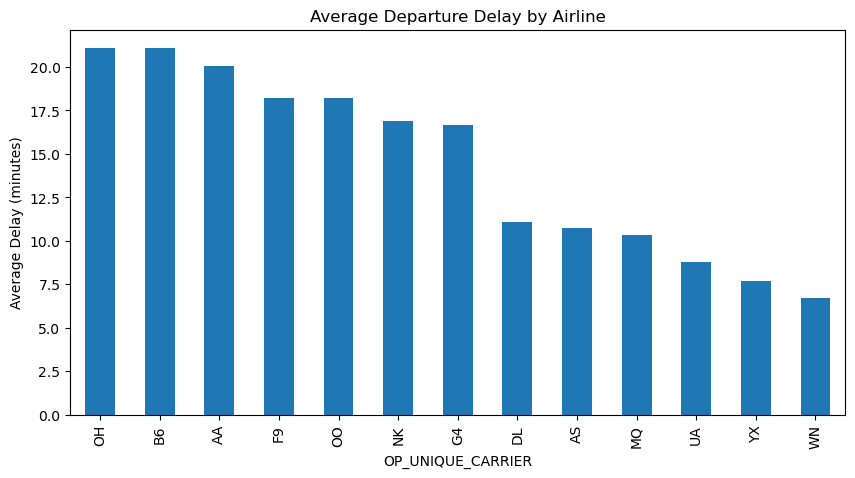

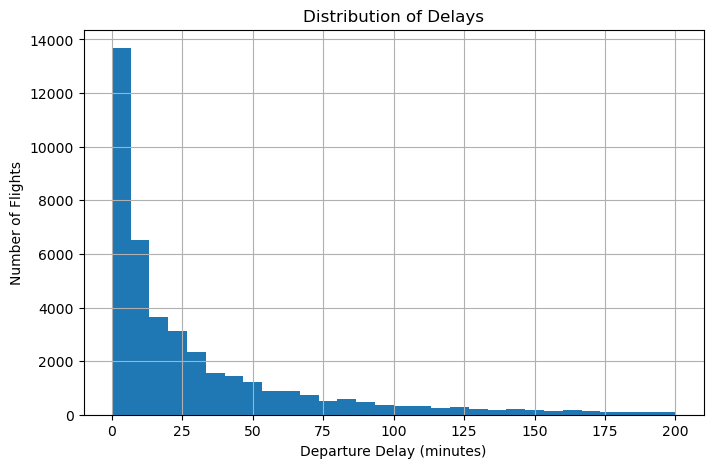

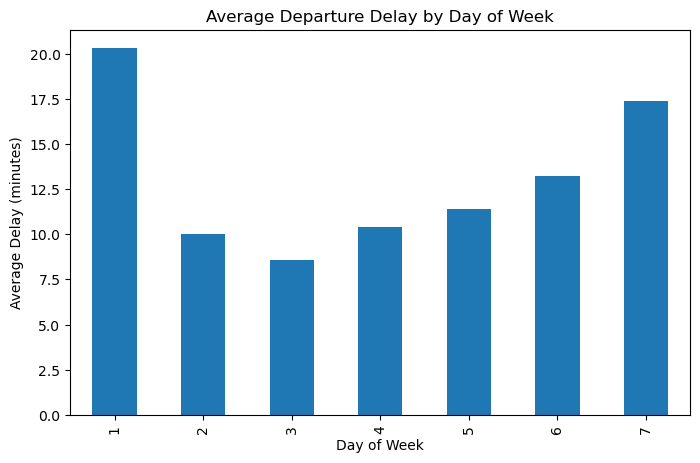

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

df = pd.read_csv(
    "data.csv",
    dtype={"CRS_DEP_TIME": str}
)


#This code filters the dataset down to 20% of the original (around 100,000 entries out of 500,000) 
#Flights are considered delayed if they are delayed by more than 15 minutes
df["Delayed"] = (df["DEP_DELAY"] > 15).astype(int)

#The proportion of delayed flights is preserved
sample, remainder = train_test_split(
    df,
    train_size=0.20,
    stratify=df["Delayed"],
    random_state=42
)

df = sample.copy()

#Preprocessing starts here
#Remove cancelled and diverted flights; they don't impact delay values
df = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)].copy()
#Scale numeric values where necessary
scaler = StandardScaler()

numeric = [
    "DISTANCE",
    "CRS_ELAPSED_TIME",
]

df[numeric] = scaler.fit_transform(df[numeric])

#Get departure hour
df["CRS_DEP_TIME"] = df["CRS_DEP_TIME"].str.zfill(4)
df["DEP_HOUR"] = df["CRS_DEP_TIME"].str[:2].astype(int)

#Make a graph showing average delay by airline
avg_delay = (
    df.groupby("OP_UNIQUE_CARRIER")["DEP_DELAY"]
      .mean()
      .sort_values(ascending=False)
)

avg_delay.plot(
    kind="bar",
    figsize=(10,5),
    title="Average Departure Delay by Airline"
)

plt.ylabel("Average Delay (minutes)")
plt.show()

#Make a graph showing distribution of delays
#Negative delays (early departures) and delays greater than 200 are not included to improve visualization 
delay = df[(df["DEP_DELAY"] >= 0) & (df["DEP_DELAY"] <= 200)]

plt.figure(figsize=(8,5))

delay["DEP_DELAY"].hist(bins=30)

plt.title("Distribution of Delays")
plt.xlabel("Departure Delay (minutes)")
plt.ylabel("Number of Flights")
plt.show()

#Make a graph showing average delay for each day of the week
avg_day = df.groupby("DAY_OF_WEEK")["DEP_DELAY"].mean()

avg_day.plot(kind="bar", figsize=(8,5))
plt.title("Average Departure Delay by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Delay (minutes)")
plt.show()
     

